<a href="https://colab.research.google.com/github/oballinger/PWTT/blob/main/pwtt_quickstart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
!pip install pwtt

In [15]:
import ee
import pwtt

project_name='<YOUR PROJECT NAME>'
ee.Authenticate()
ee.Initialize(project=project_name)

KeyboardInterrupt: 

In [ ]:
gaza = ee.Geometry.Rectangle([34.21,31.21,34.57,31.60])

pwtt.detect_damage(aoi=gaza,
                   war_start='2023-10-10',
                   inference_start='2024-05-01',
                   pre_interval=12,
                   post_interval=2,
                   viz=True)

In [ ]:
# bbox for bakhmut
bakhmut = ee.Geometry.Rectangle([37.949421, 48.556181, 38.043834, 48.621584])

pwtt.detect_damage(aoi=bakhmut,
                   war_start='2022-02-22',
                   inference_start='2024-05-01',
                   pre_interval=12,
                   post_interval=2,
                   viz=True)

In [ ]:
# Tehran — t-test (default stouffer method)
tehran = ee.Geometry.Point([51.37, 35.70]).buffer(20000)

pwtt.detect_damage(aoi=tehran,
                   war_start='2026-03-01',
                   inference_start='2026-03-01',
                   pre_interval=12,
                   post_interval=2,
                   viz=True)

In [ ]:
# Tehran — z-test (single latest image per orbit)
pwtt.detect_damage(aoi=tehran,
                   war_start='2026-03-01',
                   inference_start='2026-03-01',
                   pre_interval=12,
                   method='ztest',
                   viz=True)

Found 3 orbits: [130, 28, 35]
Sampled 5 building footprint centroids
  Orbit 130: 276 samples across 1 points
  Orbit 28: 1375 samples across 5 points
  Orbit 35: 1310 samples across 5 points


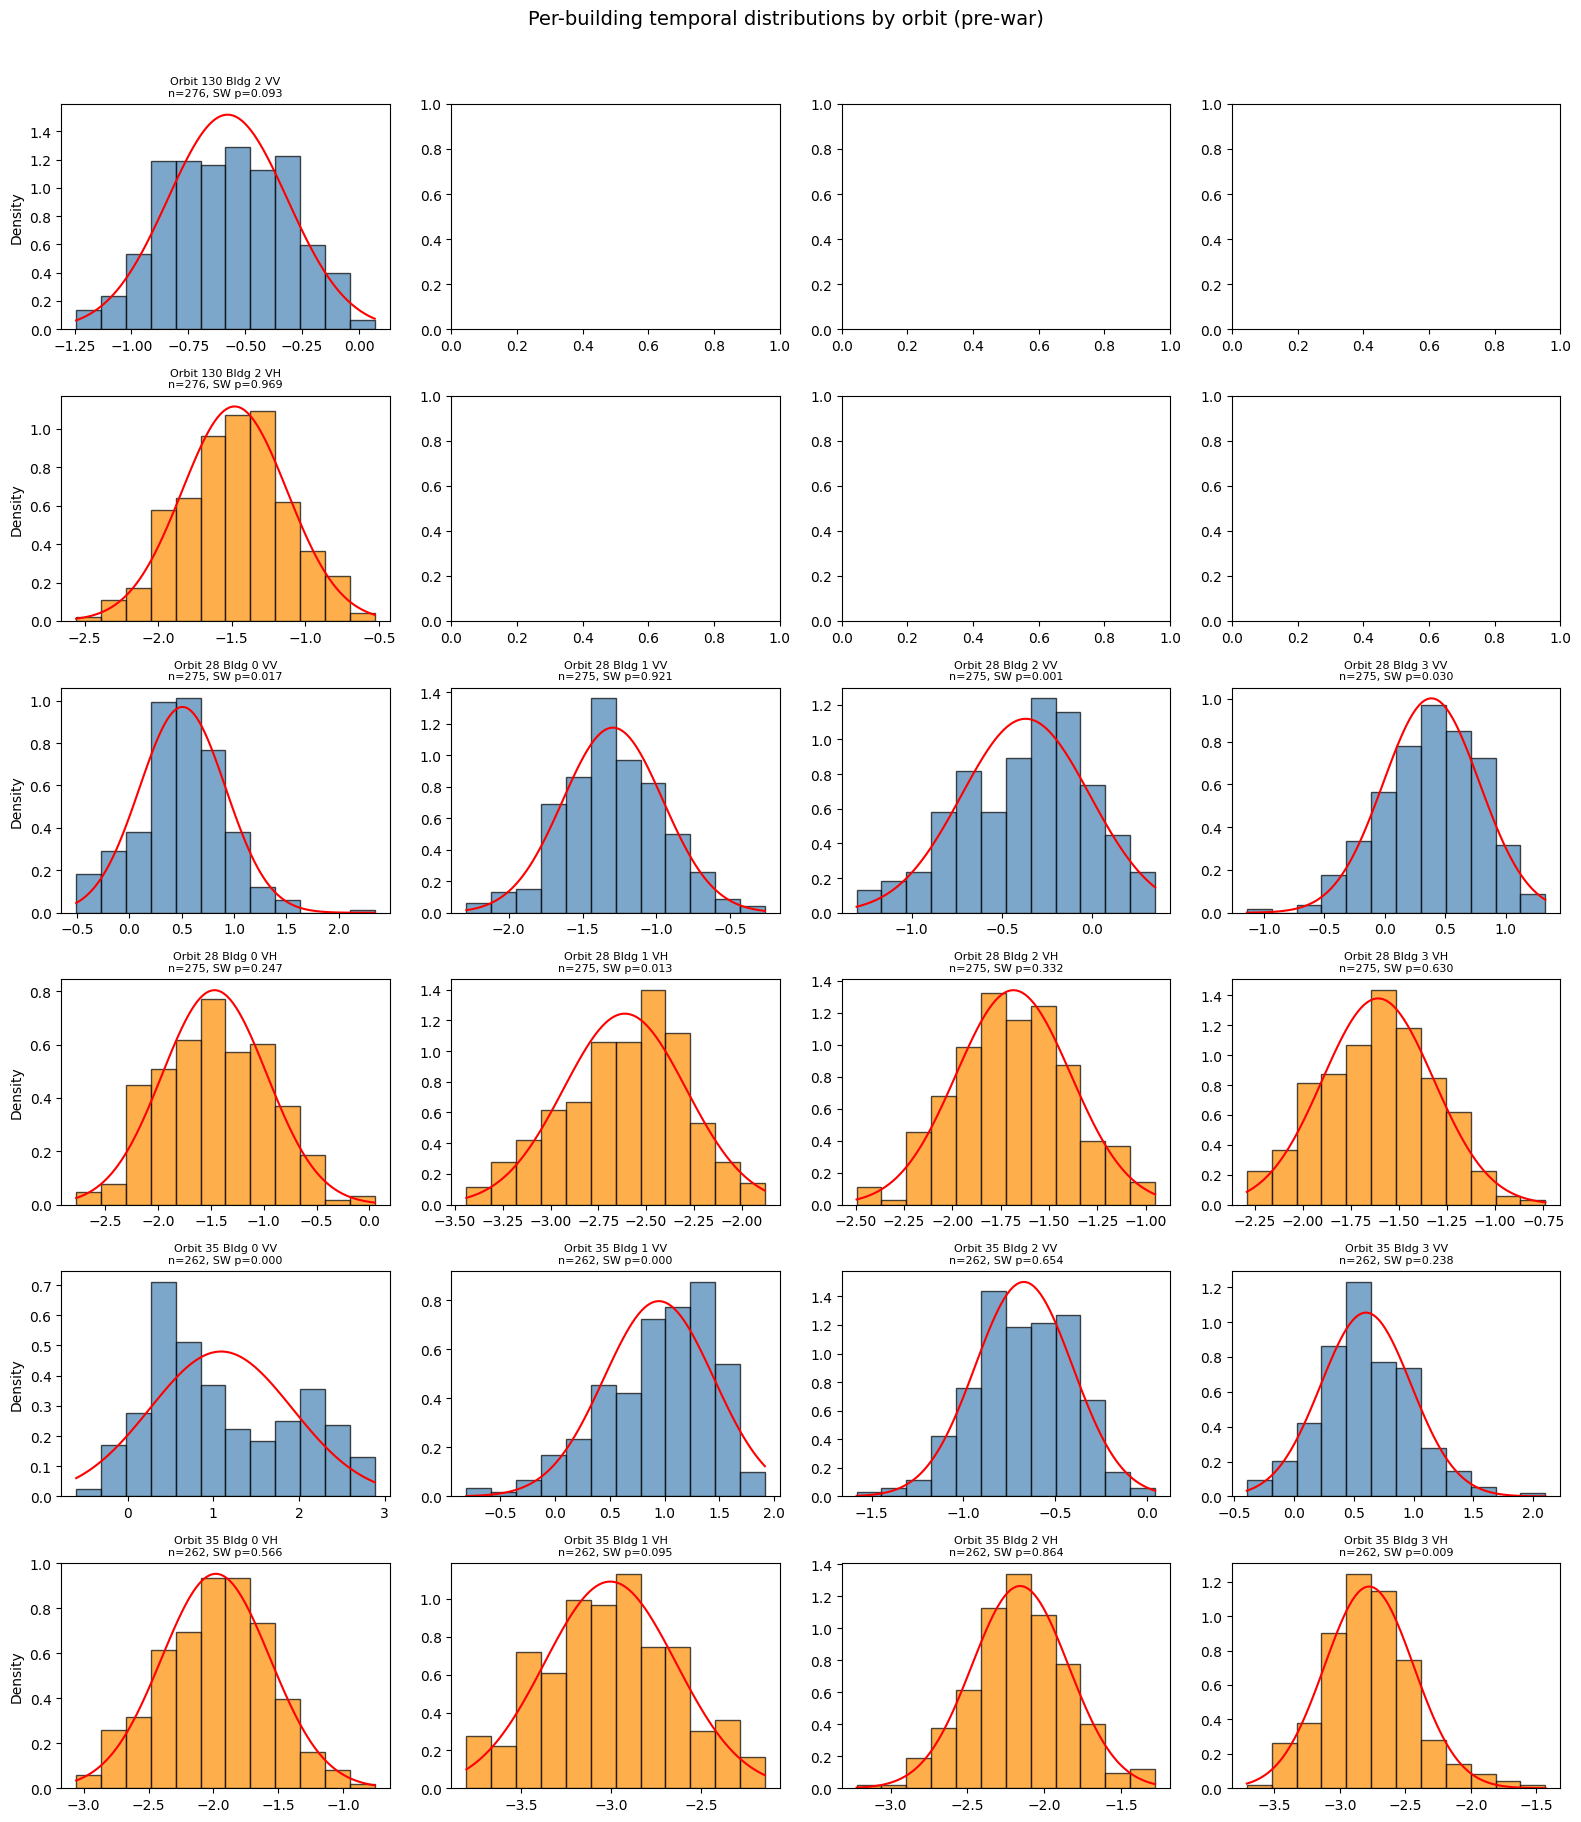


Shapiro-Wilk normality test (per orbit, per building centroid):
  Orbit 130 VV: median p=0.0928, normal (p>0.05): 100% (1 points tested)
  Orbit 130 VH: median p=0.9688, normal (p>0.05): 100% (1 points tested)
  Orbit 28 VV: median p=0.0303, normal (p>0.05): 40% (5 points tested)
  Orbit 28 VH: median p=0.2465, normal (p>0.05): 60% (5 points tested)
  Orbit 35 VV: median p=0.2377, normal (p>0.05): 60% (5 points tested)
  Orbit 35 VH: median p=0.5661, normal (p>0.05): 80% (5 points tested)


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from collections import defaultdict
import ast

tehran = ee.Geometry.Point([51.37, 35.70]).buffer(20000)
war_start = ee.Date('2026-03-01')
pre_interval = 120

# Get distinct orbits — exactly as __init__.py does
orbits = ee.ImageCollection("COPERNICUS/S1_GRD") \
    .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH")) \
    .filter(ee.Filter.eq("instrumentMode", "IW")) \
    .filterBounds(tehran) \
    .filterDate(war_start.advance(-pre_interval, 'months'), war_start) \
    .aggregate_array('relativeOrbitNumber_start') \
    .distinct().getInfo()

print(f"Found {len(orbits)} orbits: {orbits}")

# Build per-orbit collection — exactly as make_orbit_s1
def make_orbit_s1(orbit):
    return ee.ImageCollection("COPERNICUS/S1_GRD_FLOAT") \
        .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH")) \
        .filter(ee.Filter.eq("instrumentMode", "IW")) \
        .filter(ee.Filter.eq("relativeOrbitNumber_start", orbit)) \
        .map(pwtt.lee_filter) \
        .select(['VV', 'VH']) \
        .map(lambda image: image.log()) \
        .filterBounds(tehran)

# Sample 20 building footprint centroids (MS Buildings Iran)
n_points = 5
footprints = ee.FeatureCollection('projects/sat-io/open-datasets/MSBuildings/Iran') \
    .filterBounds(tehran)

# Convert to centroids and take a random sample
points = footprints.map(lambda f: ee.Feature(f.geometry().centroid(1), {'point_id': f.id()})) \
    .randomColumn('rand', seed=42).sort('rand').limit(n_points)

# Re-index point_ids sequentially for cleaner labels
points_list = points.toList(n_points)
points = ee.FeatureCollection(points_list.map(
    lambda f: ee.Feature(f).set('point_id', points_list.indexOf(f))
))

print(f"Sampled {n_points} building footprint centroids")

# For each orbit, get the pre-war time series at each point
orbit_data = {}
for orbit in orbits:
    s1 = make_orbit_s1(orbit)
    pre = s1.filterDate(war_start.advance(-pre_interval, 'months'), war_start)
    
    ts = pre.map(lambda img: img.sampleRegions(
        collection=points, scale=10, properties=['point_id']
    )).flatten().getInfo()
    
    point_vv = defaultdict(list)
    point_vh = defaultdict(list)
    for f in ts['features']:
        pid = f['properties']['point_id']
        point_vv[pid].append(f['properties']['VV'])
        point_vh[pid].append(f['properties']['VH'])
    
    orbit_data[orbit] = {'VV': dict(point_vv), 'VH': dict(point_vh)}
    print(f"  Orbit {orbit}: {len(ts['features'])} samples across {len(point_vv)} points")

# Plot: per-pixel temporal distributions, separated by orbit
n_show = min(4, n_points)
fig, axes = plt.subplots(len(orbits) * 2, n_show, figsize=(4 * n_show, 3 * len(orbits) * 2),
                         squeeze=False)
fig.suptitle('Per-building temporal distributions by orbit (pre-war)', fontsize=14, y=1.01)

row = 0
for orbit in orbits:
    for col_name, color in [('VV', 'steelblue'), ('VH', 'darkorange')]:
        pids = sorted(orbit_data[orbit][col_name].keys())[:n_show]
        for j, pid in enumerate(pids):
            ax = axes[row, j]
            vals = np.array(orbit_data[orbit][col_name][pid])
            if len(vals) < 3:
                ax.set_title(f'Orbit {orbit} Bldg {pid} {col_name}\nn={len(vals)} (too few)', fontsize=8)
                continue
            ax.hist(vals, bins=12, density=True, color=color, edgecolor='black', alpha=0.7)
            
            mu, sigma = stats.norm.fit(vals)
            x = np.linspace(vals.min(), vals.max(), 100)
            ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=1.5)
            
            _, p_sw = stats.shapiro(vals) if len(vals) >= 3 else (0, 0)
            ax.set_title(f'Orbit {orbit} Bldg {pid} {col_name}\nn={len(vals)}, SW p={p_sw:.3f}', fontsize=8)
            if j == 0:
                ax.set_ylabel('Density')
        row += 1

plt.tight_layout()
plt.show()

# Summary stats
print("\nShapiro-Wilk normality test (per orbit, per building centroid):")
for orbit in orbits:
    for col_name in ['VV', 'VH']:
        p_vals = []
        for pid, vals in orbit_data[orbit][col_name].items():
            if len(vals) >= 8:
                p_vals.append(stats.shapiro(vals)[1])
        if p_vals:
            print(f"  Orbit {orbit} {col_name}: median p={np.median(p_vals):.4f}, "
                  f"normal (p>0.05): {np.mean(np.array(p_vals) > 0.05):.0%} "
                  f"({len(p_vals)} points tested)")

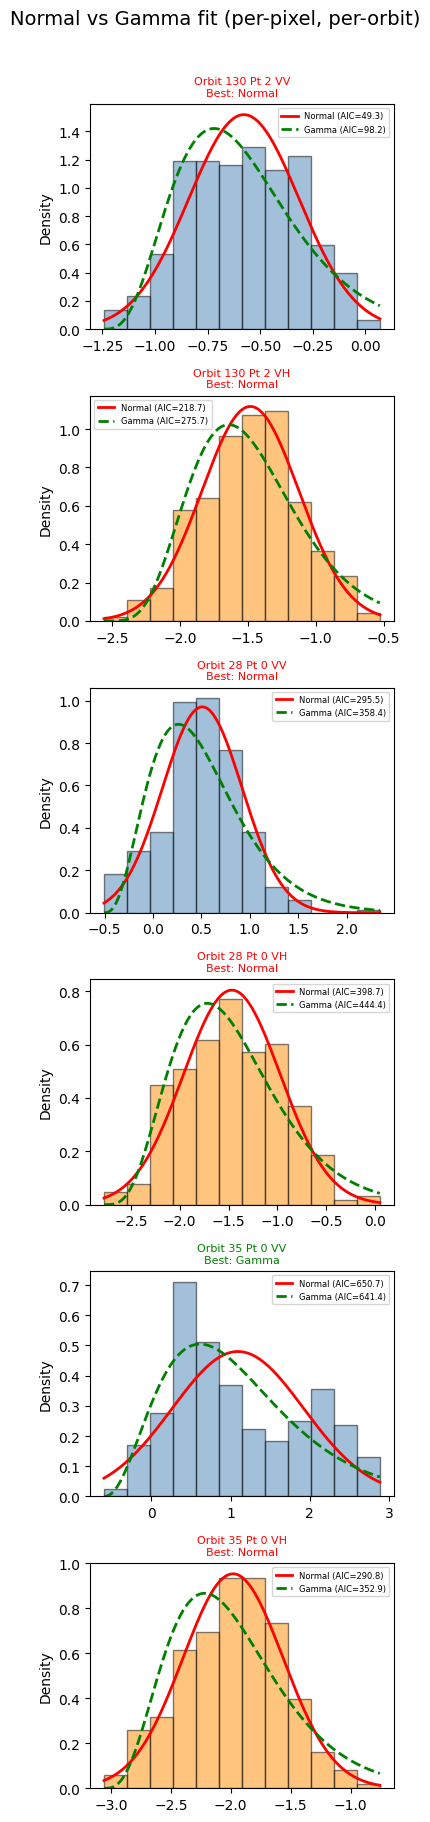


Overall: Normal wins 5, Gamma wins 1 (83% Normal)
Mean AIC difference (Normal - Gamma): -44.51 (negative = Normal better)


In [20]:
# Compare Normal vs Gamma fit for per-pixel temporal distributions (per orbit)
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

normal_wins = 0
gamma_wins = 0
all_results = []

n_show = min(4, len(list(orbit_data.values())[0]['VV']))
fig, axes = plt.subplots(len(orbits) * 2, n_show, figsize=(4 * n_show, 3 * len(orbits) * 2), squeeze=False)
fig.suptitle('Normal vs Gamma fit (per-pixel, per-orbit)', fontsize=14, y=1.01)

row = 0
for orbit in orbits:
    for col_name, color in [('VV', 'steelblue'), ('VH', 'darkorange')]:
        pids = sorted(orbit_data[orbit][col_name].keys())[:n_show]
        for j, pid in enumerate(pids):
            ax = axes[row, j]
            vals = np.array(orbit_data[orbit][col_name][pid])
            if len(vals) < 8:
                ax.set_title(f'Orbit {orbit} Pt {pid} {col_name}\ntoo few samples', fontsize=8)
                continue

            # Data is log-transformed (can be negative), so shift for gamma fit
            shift = vals.min() - 0.01  # gamma needs positive values
            vals_shifted = vals - shift

            # Fit normal
            mu_n, sig_n = stats.norm.fit(vals)
            # Fit gamma (on shifted data)
            a_g, loc_g, scale_g = stats.gamma.fit(vals_shifted, floc=0)

            # Log-likelihood comparison
            ll_norm = np.sum(stats.norm.logpdf(vals, mu_n, sig_n))
            ll_gamma = np.sum(stats.gamma.logpdf(vals_shifted, a_g, loc=0, scale=scale_g))

            # AIC: -2*LL + 2*k (normal: k=2, gamma: k=2)
            aic_norm = -2 * ll_norm + 4
            aic_gamma = -2 * ll_gamma + 4

            winner = 'Normal' if aic_norm < aic_gamma else 'Gamma'
            if aic_norm < aic_gamma:
                normal_wins += 1
            else:
                gamma_wins += 1
            all_results.append(dict(orbit=orbit, band=col_name, pid=pid,
                                     aic_norm=aic_norm, aic_gamma=aic_gamma, winner=winner))

            # Plot
            x = np.linspace(vals.min(), vals.max(), 200)
            ax.hist(vals, bins=12, density=True, color=color, edgecolor='black', alpha=0.5)
            ax.plot(x, stats.norm.pdf(x, mu_n, sig_n), 'r-', lw=2, label=f'Normal (AIC={aic_norm:.1f})')
            ax.plot(x, stats.gamma.pdf(x - shift, a_g, loc=0, scale=scale_g), 'g--', lw=2,
                    label=f'Gamma (AIC={aic_gamma:.1f})')
            ax.set_title(f'Orbit {orbit} Pt {pid} {col_name}\nBest: {winner}', fontsize=8,
                         color='red' if winner == 'Normal' else 'green')
            ax.legend(fontsize=6)
            if j == 0:
                ax.set_ylabel('Density')
        row += 1

plt.tight_layout()
plt.show()

print(f"\nOverall: Normal wins {normal_wins}, Gamma wins {gamma_wins} "
      f"({100*normal_wins/(normal_wins+gamma_wins):.0f}% Normal)")
print(f"Mean AIC difference (Normal - Gamma): "
      f"{np.mean([r['aic_norm'] - r['aic_gamma'] for r in all_results]):.2f} "
      f"(negative = Normal better)")